# The state of the store

What has been built out of OpenStreetMap so far, what it fixed, what is
still open, and what each of those numbers looks like on the ground.

Every number here is read from the live PostGIS store, and every one that
also appears in `review/README.md` is **the same query** — the metric
definitions are imported from `export.review_bundle` rather than retyped,
so the two cannot drift apart. Colours come from the `*_class` columns the
`qa.v_*` views already carry, which is what QGIS colours by, for the same
reason.

Refresh it with:

```
cd pipeline
uv run --group notebook jupyter nbconvert --to notebook --execute \
    --inplace notebooks/state.ipynb
uv run --group notebook jupyter nbconvert --to html \
    notebooks/state.ipynb --output state.html
```

Two steps, and in that order: the first runs the notebook and keeps its
outputs, the second renders those same outputs to HTML. Executing twice
would leave the page and the notebook reporting two different runs.

In [1]:
import sys
from pathlib import Path

# This is a non-packaged uv project with flat modules, so `core` and
# `export` only resolve from pipeline/. nbconvert runs with the notebook's
# own directory as cwd, so find the root rather than assuming it.
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "core.py").exists())
sys.path[:0] = [str(root), str(root / "notebooks")]

import pandas as pd
import review_data as rd

%matplotlib inline
pd.set_option("display.max_colwidth", 90)

rd.frame("SELECT to_char(now(), 'YYYY-MM-DD HH24:MI') AS generated")

,generated
0,2026-08-23 08:45


**How fresh this is.** Every builder that has run over the store, and when
it last did. A page that cannot say how old it is fails the same way a
review bundle that lags the database does: it looks current.

In [2]:
rd.builders()

,builder,last_run,runs,last_counts
0,curate.places,2026-08-22,2,"{'places': 17697, 'starts': 10489, 'start_vertices': 8110}"
1,export.neo4j_load,2026-08-21,4,"{'passes': 29456, 'places': 8156, 'routes': 980, 'starts': 276}"
2,export.route_documents,2026-08-21,5,"{'routes': 752, 'with_warnings': 214}"
3,draw.generate,2026-08-20,6,"{'kept': 70, 'routes': 43, 'starts': 12, 'targets': [5000.0, 10000.0, 15000.0]}"
4,build_network,2026-08-19,2,"{'edges': 101870, 'vertices': 80124, 'components': 407, 'largest_component_share': 0.984}"
5,curate.elevation,2026-08-19,1,"{'ascent_m': 592685.0, 'descent_m': 555837.0, 'km_unknown': 56.8, 'with_climb': 101876..."
6,curate.routes,2026-08-19,2,"{'km': 2469.5, 'edges': 17118, 'links': 25719, 'routes': 752, 'relations': 752, 'newly..."


## 1 · What there is

The ten numbers the build is measured by. **Network length is the integrity
check**: a pass that moves it has either invented ground or thrown some
away, which is why every repair is judged against it staying still.

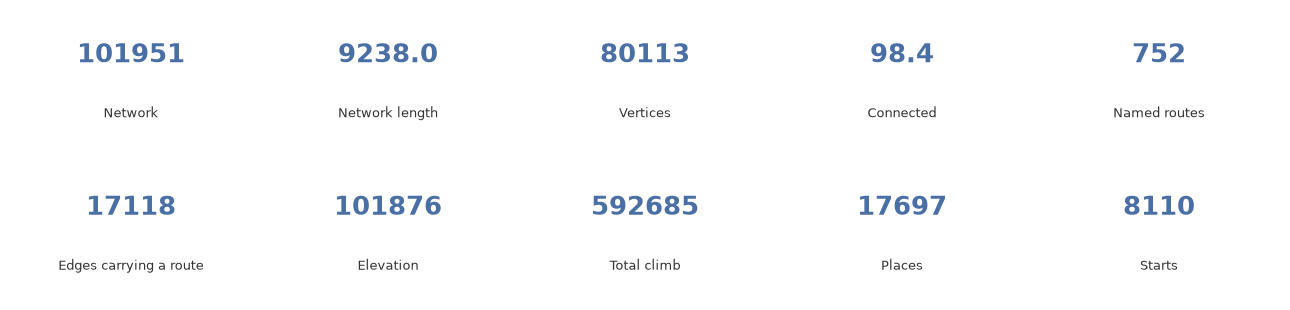

In [3]:
rd.stat_tiles(rd.metrics("state"))

In [4]:
rd.metrics("state")[["label", "note"]]

,label,note
0,Network,edges
1,Network length,km - **the integrity check**: a pass that moves this has either invented ground or thr...
2,Vertices,routing nodes
3,Connected,% of vertices in the largest component
4,Named routes,route relations joined onto the network
5,Edges carrying a route,edges with a name from a relation
6,Elevation,edges with ascent and descent
7,Total climb,metres of ascent across the network
8,Places,"POIs, settlements and stops snapped"
9,Starts,vertices a walk can begin at


## 2 · Where it is

The whole routing network in one frame, coloured by steepness, with the two
ingested regions boxed and every start drawn as a dot. Lecco and Bergamo
are one connected network, not two — which is why a route can cross
between them.

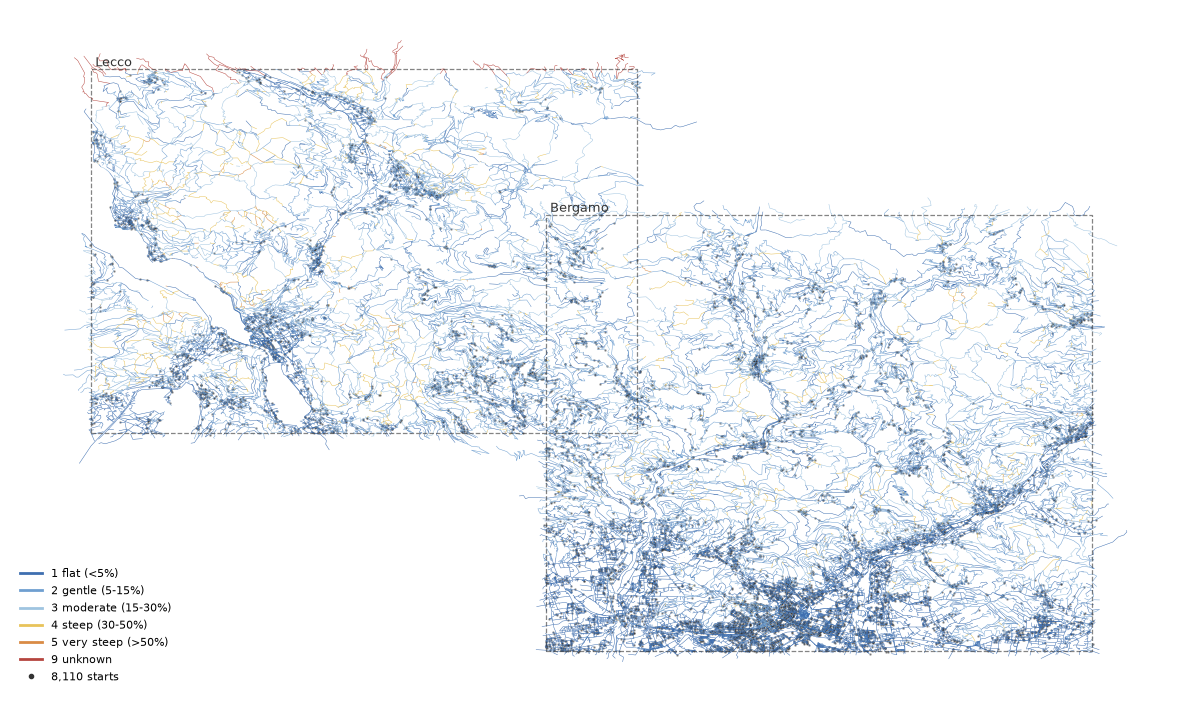

In [5]:
network = rd.geoframe(
    """
    SELECT edge_id, steepness_class,
           ST_SimplifyPreserveTopology(geom, 0.0004) AS geom
    FROM qa.v_network
    """
)
starts = rd.geoframe("SELECT vertex_id, geom FROM qa.v_start")
rd.network_map(network, starts)

## 3 · How it got here

Findings are kept per run, so the repair history is a query rather than a
note somebody wrote down. Four rules were driven to zero; islands drift
down as coverage widens; **overlap is the one that moved the wrong way**,
and it is the queue that is still open below.

Green means the rule now reports nothing.

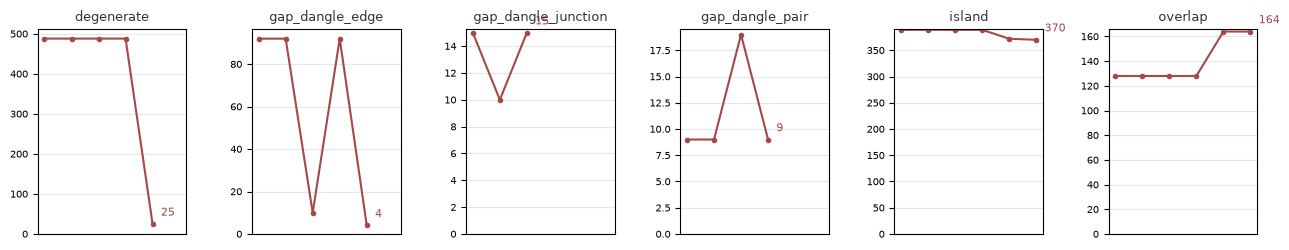

In [6]:
rd.history_chart(rd.finding_history())

## 4 · What is settled

The claims this build has earned. The repairs are the load-bearing one: a
detector that finds a defect is worth little unless the fix can be shown
not to have moved the ground underneath it.

In [7]:
rd.metrics("settled")[["label", "value", "note"]]

,label,value,note
0,Every repairable topology defect is at zero,0,findings across the four repairable rules - and the network kept every metre while the...
1,Route relations joined,752,"of 752, with 10,361 edges that had no name of their own now carrying one"
2,The DEM agrees with the ground,160,saddles checked against their OSM `ele` tag: median error 4.1 m. Judge the DEM on sadd...
3,Every staged source is read by something,7,"distinct builders have run over this store - ways, relations, the DEM, POIs, settlemen..."


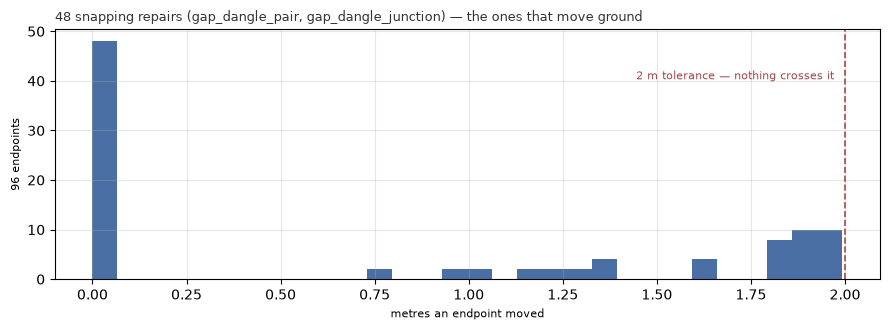

In [8]:
fixes = rd.frame(
    "SELECT fix_id, rule, start_moved_m, end_moved_m FROM qa.v_fix"
)
rd.fix_histogram(fixes)

The tolerance is not a guess: 2 m came from the near-miss histogram, where
231 of 14,769 loose ends fall inside it and the distribution's own peak sits
at 6–8 m — deep inside the real-dead-end population. Nothing crosses the
line, so no repair reached past the evidence for it.

**Only two of the four repair rules are on that chart, and that is the
point.** `gap_dangle_pair` and `gap_dangle_junction` MOVE an endpoint, so
the tolerance binds them. The other two do not move anything:
`gap_dangle_edge` splits an edge at a point and `degenerate` collapses a
sub-metre one, so their `end_moved_m` measures the piece that resulted, not
a distance the ground travelled. Read together, the four say a repair moved
something 555 m — which never happened. The bundle's blanket *nothing
should have moved more than the 2 m tolerance* is true of the snaps and
misleading over all four.

## 5 · What is open, and where

Ordered by how much each matters, not by size — a zero here is good news.
The scale is logarithmic because they span 12 to 7,170.

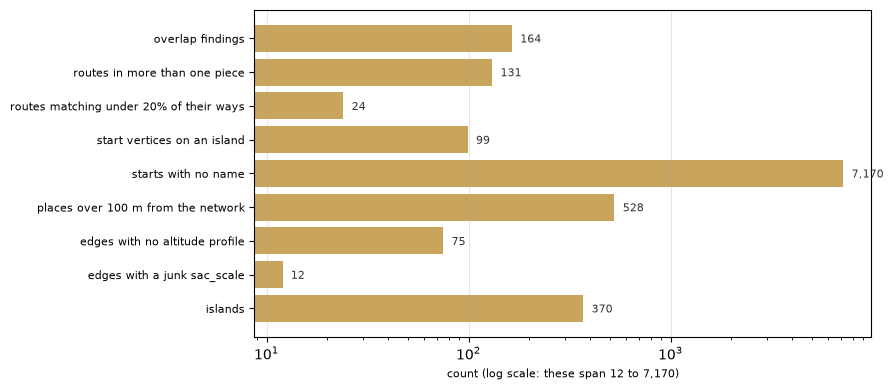

In [9]:
rd.issues_bar(rd.metrics("issues"))

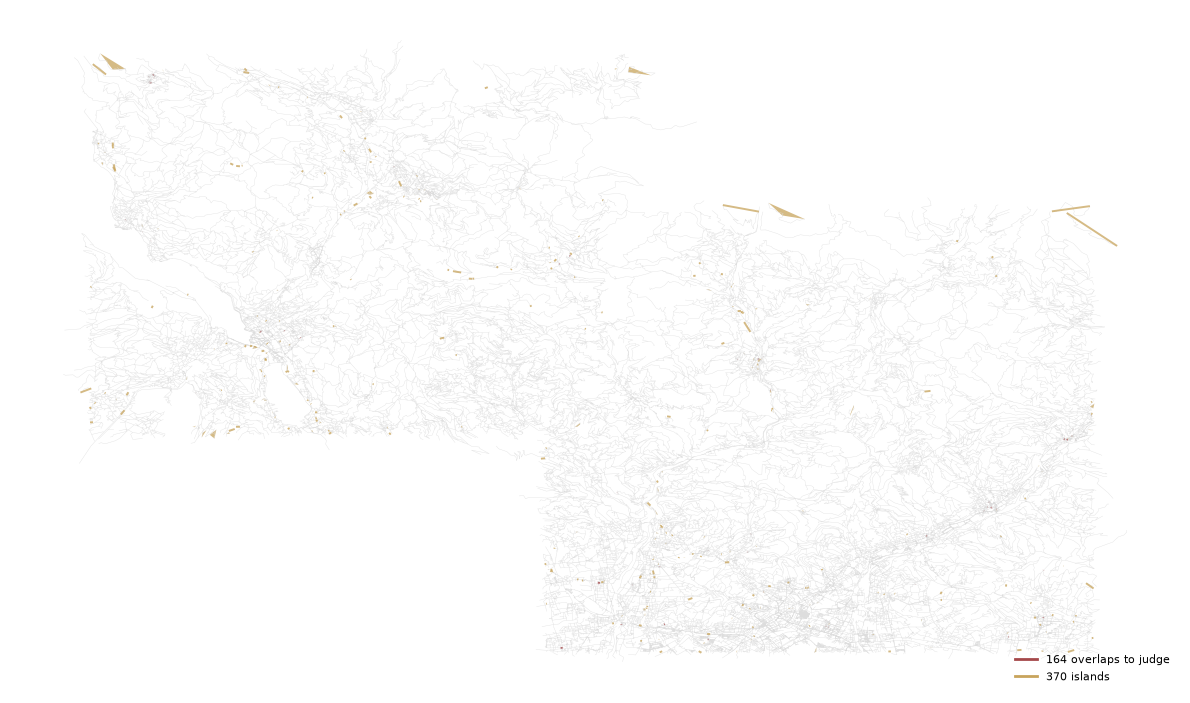

In [10]:
overlaps = rd.geoframe(
    "SELECT finding_id, shared_m, geom FROM qa.v_overlap"
)
islands = rd.geoframe(
    "SELECT finding_id, vertices, geom FROM qa.v_island"
)
rd.findings_map(
    network, {"overlaps to judge": overlaps, "islands": islands}
)

Overlap is the one queue no rule can close: a duplicate, a bridge and two
ways legitimately sharing a stretch look identical from the outside. Islands
are deliberately **not** repaired — welding one to the network would invent
a connection that is not there.

## 6 · What a number looks like on the ground

A count is a claim about real ground. Six of them, each drawn over the
network around it and captioned with the measure that picked it out.

In the repair panel, grey dashed is where the endpoint was and red is where
it is. In the urban-exit panel, green is a way out onto trail and grey is
the town continuing — the judgement the start rule asks for.

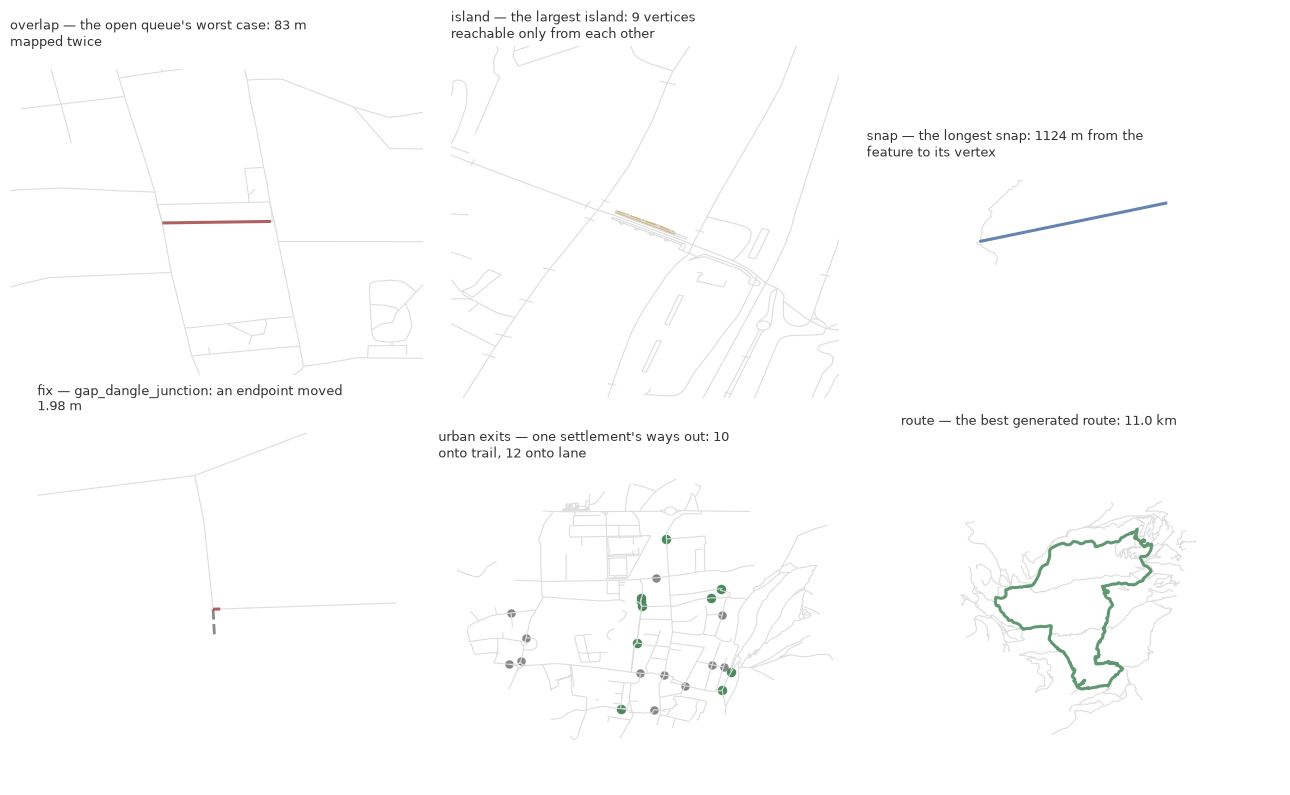

In [11]:
rd.examples_figure()

## 7 · The catalogue

The routes generated from those starts: how long, how much climb, and how
much of each stays off the road. Score is descriptive and never a filter —
what counts as enough trail is a product decision, not a build step's.

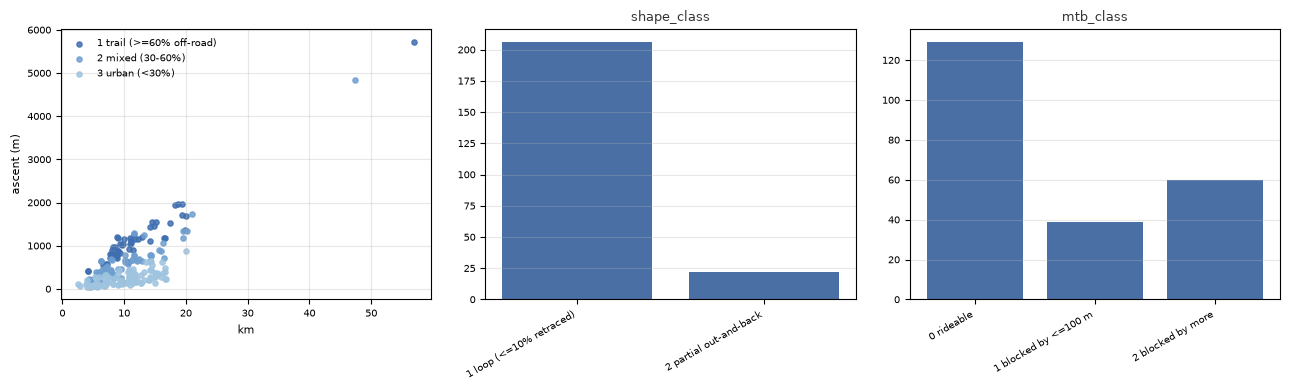

In [12]:
draw = rd.geoframe(
    """
    SELECT route_id, km, ascent_m, off_road_share, score,
           offroad_class, shape_class, mtb_class, geom
    FROM qa.v_draw
    """
)
rd.catalogue_charts(draw)

---

**Where to look next.** The open list above is ordered on purpose: the 164
overlaps are the only queue that needs a person, and the routes matching
under 20% of their ways are the ones that would ship a fragment under a
famous name. Everything below those is coverage or naming — real, and not
in the way.

For judging one geometry at a time, this page is the wrong tool: open
`review/vaivia-qa.gpkg` in QGIS and sort the layer by its measure. This one
answers where the build is; that one answers whether a particular line is
right.